# Computational Statistics & Data Analysis - Exercise Sheet 4

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sym
import math
import time

#### Choose the health indicators: Adult Mortalilty and infant deaths

In [24]:
df = pd.read_csv("life_expectancy.csv")
df_relevant=df[['Year','Life expectancy ','Adult Mortality','infant deaths']].dropna()
df_relevant

,Year,Life expectancy,Adult Mortality,infant deaths
0,2015,65.0,263.0,62
1,2014,59.9,271.0,64
2,2013,59.9,268.0,66
3,2012,59.5,272.0,69
4,2011,59.2,275.0,71
...,...,...,...,...
2933,2004,44.3,723.0,27
2934,2003,44.5,715.0,26
2935,2002,44.8,73.0,25
2936,2001,45.3,686.0,25


In [11]:
y=df_relevant['Life expectancy '].to_numpy()
x1=df_relevant['Adult Mortality'].to_numpy()
x2=df_relevant['infant deaths'].to_numpy()

## 1.) using least squares estimate
obtain an estimate for $\beta_0,\beta_1,\beta_2$ and $\sigma^2$ using a least squares estimate for the model:

$y=\beta_0+\beta_1x_1+\beta_2x_2+\epsilon$

In [20]:
N=len(y)
X=np.column_stack((np.ones(N),x1,x2))

inv=np.linalg.inv(X.T@X)
beta_est=inv@X.T@y

var_est=(y-X@beta_est).T@(y-X@beta_est)/(N-3)  # from Chat-Gpt (maybe upload lecture notes?)

beta_est,var_est

(array([ 7.82260313e+01, -5.24979201e-02, -1.14981323e-02]),
 44.917887801165605)

## 2.) using  Bayesian parameter update loop for the joint posterior

In [ ]:
def bayes_update(X, y, mu, Sigma, alpha, kappa):

    n, d = X.shape

    Sigma_inv = np.linalg.inv(Sigma)

    # posterior covariance
    Sigma_new = np.linalg.inv(X.T @ X + Sigma_inv)

    # posterior mean
    mu_new = Sigma_new @ (X.T @ y + Sigma_inv @ mu)

    # sigma^2 update
    alpha_new = alpha + n / 2

    residual_term = y.T @ y + mu.T @ Sigma_inv @ mu - mu_new.T @ np.linalg.inv(Sigma_new) @ mu_new
    kappa_new = kappa + 0.5 * residual_term

    return mu_new, Sigma_new, alpha_new, kappa_new

In [30]:
def bayesion_update(X,y,Lambda,beta,kappa,alpha):
    """Function does bayesion update and returns Lambda_N,beta_N,kappa_N,alpha_N"""
    n=len(y)
    
    #calculate new Lambda
    Lambda_N=X.T@X+Lambda
    
    #calculate new beta
    Lambda_N_inv=np.linalg.inv(Lambda_N)
    beta_N=Lambda_N_inv@(X.T@y+Lambda@beta)
    
    #calculate new kappa
    kappa_N=kappa+0.5*(y.T@y+beta.T@Lambda@beta-beta_N@Lambda_N@beta_N)
    
    #calculate new alpha
    alpha_N=alpha+n/2
    
    return Lambda_N,beta_N,kappa_N,alpha_N

#### We're not really sure what you want us to do.

In [47]:
years = sorted(df_relevant["Year"].unique())

d = 3  # beta0, beta1, beta2
beta = np.ones(d)
Lambda = np.eye(d)
alpha = 1.0
kappa = 1.0

posterior_betas = np.zeros((3,len(years)))

for i in range(len(years)):
    df_year = df_relevant[df_relevant["Year"] == years[i]]
    
    y = df_year['Life expectancy '].values
    N=len(y)
    x1=df_year['Adult Mortality'].values
    x2=df_year['infant deaths'].values
    
    X = np.column_stack((np.ones(N),x1,x2))

    Lambda,beta,kappa,alpha = bayesion_update(X,y,Lambda,beta,kappa,alpha)

    posterior_betas[0,i],posterior_betas[1,i],posterior_betas[2,i]=beta

In [48]:
posterior_betas

array([[ 7.42891652e+01,  7.48945640e+01,  7.51222427e+01,
         7.51062633e+01,  7.56814573e+01,  7.57505878e+01,
         7.60084878e+01,  7.61979580e+01,  7.65919105e+01,
         7.68805052e+01,  7.71468890e+01,  7.74103540e+01,
         7.75907001e+01,  7.77536860e+01,  7.79510962e+01,
         7.81527180e+01],
       [-4.18115087e-02, -4.36548539e-02, -4.43416739e-02,
        -4.40398509e-02, -4.60759055e-02, -4.58589969e-02,
        -4.63939251e-02, -4.68886838e-02, -4.80202572e-02,
        -4.87831820e-02, -4.96219401e-02, -5.04070267e-02,
        -5.08489034e-02, -5.11873043e-02, -5.16993915e-02,
        -5.22192870e-02],
       [-9.36625947e-03, -1.00100896e-02, -1.02330126e-02,
        -1.00874032e-02, -1.00749160e-02, -1.03848929e-02,
        -1.07607987e-02, -1.09885464e-02, -1.11516112e-02,
        -1.13337558e-02, -1.12587270e-02, -1.12235858e-02,
        -1.14100123e-02, -1.13966119e-02, -1.14322882e-02,
        -1.14637477e-02]])

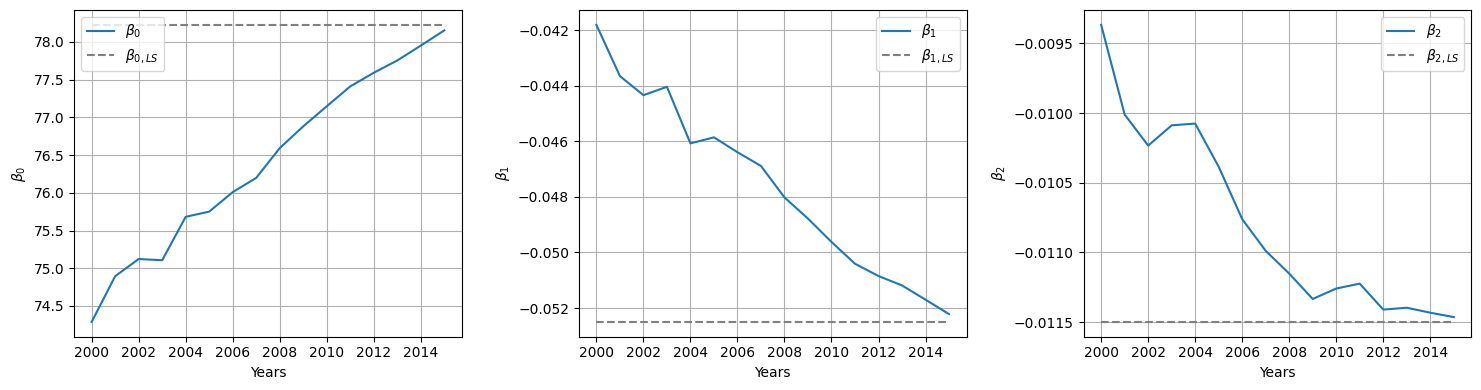

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(years,posterior_betas[0],label=r"$\beta_0$")
axes[0].hlines(beta_est[0],2000,2015,ls="--",color="grey",label=r"$\beta_{0,LS}$")

axes[0].set_xlabel("Years")
axes[0].set_ylabel(r"$\beta_0$")
axes[0].grid()
axes[0].legend()

axes[1].plot(years,posterior_betas[1],label=r"$\beta_1$")
axes[1].hlines(beta_est[1],2000,2015,ls="--",color="grey",label=r"$\beta_{1,LS}$")

axes[1].set_xlabel("Years")
axes[1].set_ylabel(r"$\beta_1$")
axes[1].grid()
axes[1].legend()

axes[2].plot(years,posterior_betas[2],label=r"$\beta_2$")
axes[2].hlines(beta_est[2],2000,2015,ls="--",color="grey",label=r"$\beta_{2,LS}$")

axes[2].set_xlabel("Years")
axes[2].set_ylabel(r"$\beta_2$")
axes[2].grid()
axes[2].legend()

plt.tight_layout()
plt.show()